# ADL benchmarks on **graphed** — interactive exploration

The eight [IRIS-HEP ADL functionality benchmarks](https://github.com/iris-hep/adl-benchmarks-index)
expressed as **deferred graphed computations** (mirroring this repository's original
`coffea-adl-benchmarks.ipynb`): each query records into the graphed IR through
`uproot.graphed` + `graphed_awkward.gak` + vector behaviors, fills a deferred `hist.graphed`
histogram, and is aggregated partition by partition by an executor. Nothing below materializes
the dataset — reads are projected to exactly the branches each query touches.

Data: a committed 50k-event skim of `Run2012B_SingleMu.root` (`data/Run2012B_SingleMu_50k.root`).
The acceptance tests pin every histogram **bit for bit** against the original coffea processors.

In [1]:
import inspect

import matplotlib.pyplot as plt
import uproot

import adl_graphed as adl

WHERE = "data/Run2012B_SingleMu_50k.root:Events"
g = uproot.graphed(WHERE, library="ak", behavior=adl.behavior())
g

Array(node_id=0)

## Exploring the deferred array

`g` is a lazy record of the TTree's branches. Operations **record** instead of executing;
forms are inferred by awkward's typetracer, and the buffer projection reports exactly what a
result would read.

In [2]:
from graphed_awkward import gak

muons = adl.muons(g)          # zip the muon kinematics into a Momentum4D collection
print("form:", g.session.form(muons).describe()[:90])
print("pt of a four-vector property touches:", uproot.necessary_columns(muons.pt))
print("but .px (a DERIVED property) touches:", uproot.necessary_columns(muons.px))

form: ## * var * Momentum4D[pt: float32, eta: float32, phi: float32, mass: float32, charge: int3
pt of a four-vector property touches: {'Events': frozenset({'Muon_pt'})}
but .px (a DERIVED property) touches: {'Events': frozenset({'Muon_pt', 'Muon_phi'})}


In [3]:
# peek at the first events WITHOUT reading the rest of the file
import awkward as ak
ak.Array(uproot.graphed_head(muons.pt, 5)).tolist()

[[12.77709674835205],
 [24.76300621032715],
 [37.74860382080078,
  6.9919257164001465,
  3.349816083908081,
  7.9132561683654785,
  5.379203796386719,
  9.373967170715332],
 [30.48163414001465],
 [33.53227615356445]]

In [4]:
# the compiled IR is a handful of fused stages, not one node per recorded op
import graphed_core
from graphed import compile_ir

expr = (adl.muons(g).pt > 30.0)
nodes = graphed_core.GraphStore.deserialize(compile_ir(g.session, expr).ir).nodes()
[(n["kind"], n.get("n_members", "")) for n in nodes]

[('source', ''), ('stage', 8)]

## **Q1** — Plot the missing transverse energy of all events.

In [5]:
print(inspect.getsource(adl.QUERIES["q1"]))

def q1(g: Any) -> Any:
    """MET of all events."""
    return hg.Hist.new.Reg(100, 0, 200, name="met", label=r"$E_{T}^{miss}$ [GeV]").Double().fill(
        met=g.MET_pt
    )



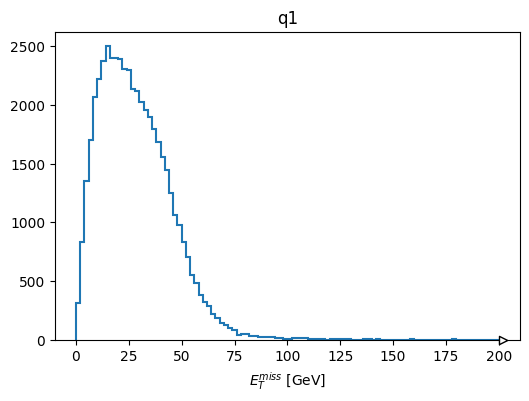

In [6]:
out = adl.run_query("q1", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q2** — Plot the $p_T$ of all jets (ragged fills flatten).

In [7]:
print(inspect.getsource(adl.QUERIES["q2"]))

def q2(g: Any) -> Any:
    """pT of all jets (ragged fills flatten)."""
    return hg.Hist.new.Reg(100, 0, 200, name="ptj", label=r"Jet $p_{T}$ [GeV]").Double().fill(
        ptj=g.Jet_pt
    )



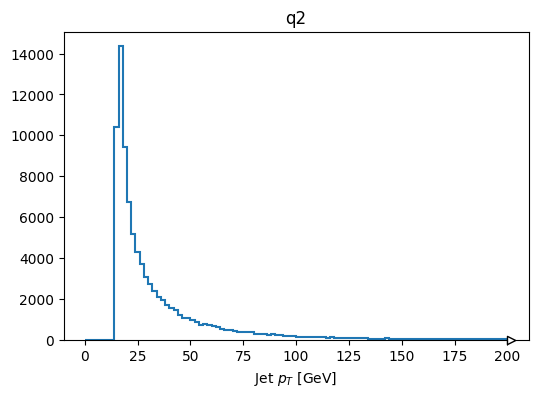

In [8]:
out = adl.run_query("q2", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q3** — Plot the $p_T$ of jets with $|\eta| < 1$.

In [9]:
print(inspect.getsource(adl.QUERIES["q3"]))

def q3(g: Any) -> Any:
    """pT of jets with |eta| < 1."""
    sel = g.Jet_pt[abs(g.Jet_eta) < 1.0]
    return hg.Hist.new.Reg(100, 0, 200, name="ptj", label=r"Jet $p_{T}$ [GeV]").Double().fill(ptj=sel)



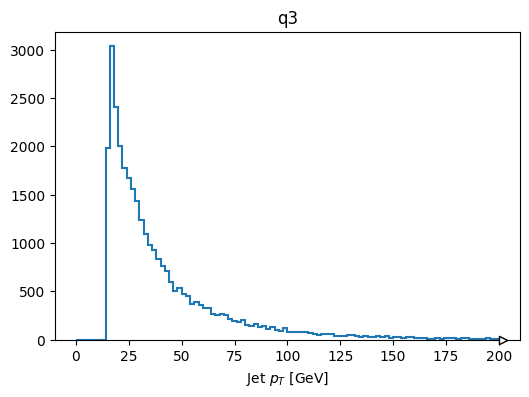

In [10]:
out = adl.run_query("q3", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q4** — Plot the MET of events with at least two jets above 40 GeV.

In [11]:
print(inspect.getsource(adl.QUERIES["q4"]))

def q4(g: Any) -> Any:
    """MET of events with >= 2 jets above 40 GeV."""
    has2jets = gak.sum(g.Jet_pt > 40.0, axis=1) >= 2
    return hg.Hist.new.Reg(100, 0, 200, name="met", label=r"$E_{T}^{miss}$ [GeV]").Double().fill(
        met=g.MET_pt[has2jets]
    )



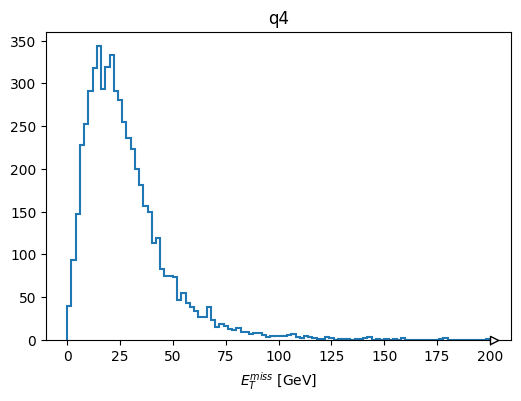

In [12]:
out = adl.run_query("q4", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q5** — Plot the MET of events with an opposite-charge dimuon pair with mass 60–120 GeV.

In [13]:
print(inspect.getsource(adl.QUERIES["q5"]))

def q5(g: Any) -> Any:
    """MET of events with an opposite-charge dimuon pair with 60 < m < 120 GeV."""
    mu = muons(g)
    pair = gak.combinations(mu, 2, fields=["mu1", "mu2"])
    mass = (pair.mu1 + pair.mu2).mass
    opposite = pair.mu1.charge != pair.mu2.charge
    good = gak.any((mass > 60.0) & (mass < 120.0) & opposite, axis=1)
    return hg.Hist.new.Reg(100, 0, 200, name="met", label=r"$E_{T}^{miss}$ [GeV]").Double().fill(
        met=g.MET_pt[good]
    )



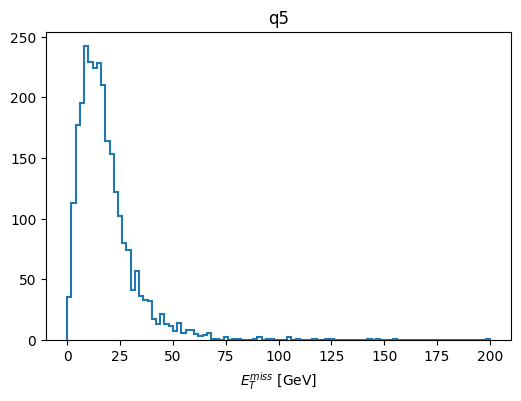

In [14]:
out = adl.run_query("q5", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q6** — For events with ≥3 jets: the $p_T$ of the trijet closest to the top mass, and its maximum b-tag.

In [15]:
print(inspect.getsource(adl.QUERIES["q6"]))

def q6(g: Any) -> dict[str, Any]:
    """The trijet closest to the top mass: its pT and its max b-tag.

    Mirrors upstream EXACTLY: the jets are re-zipped into CARTESIAN components (x, y, z, t)
    before summing — summing in pt/eta/phi/mass coordinates rounds differently at the ULP level
    and flips argmin picks between near-equidistant trijet candidates (a Linux-manifest finding;
    modern coffea's LorentzVector methods are vector's, so the derived components match)."""
    p4j = jets(g, btag=True)
    jet = gak.zip(
        {"x": p4j.x, "y": p4j.y, "z": p4j.z, "t": p4j.t, "btag": p4j.btag},
        with_name="Momentum4D",
    )
    tri = gak.combinations(jet, 3, fields=["j1", "j2", "j3"])
    p4 = tri.j1 + tri.j2 + tri.j3
    best = gak.argmin(abs(p4.mass - 172.5), axis=1, keepdims=True)
    best_pt = gak.flatten(p4.pt[best])
    max_btag = gak.flatten(
        np.maximum(tri.j1.btag, np.maximum(tri.j2.btag, tri.j3.btag))[best]
    )
    h_pt = hg.Hist.new.Reg(100, 0, 200, name

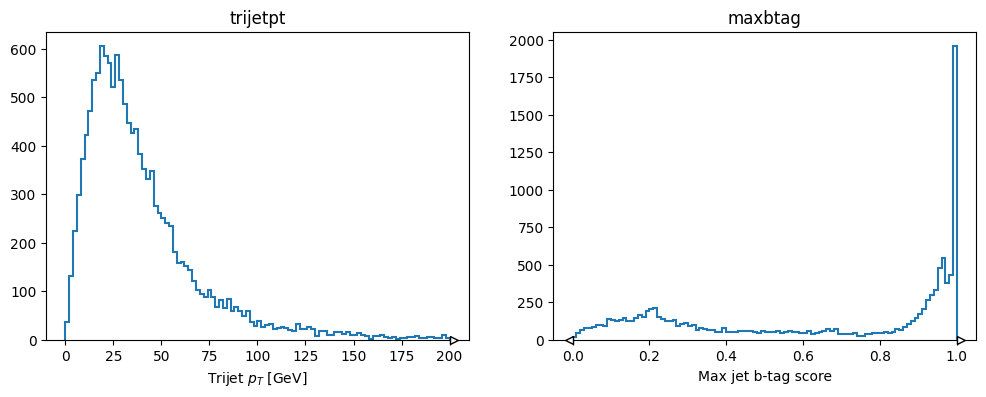

In [16]:
out = adl.run_query("q6", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q7** — Scalar sum of jet $p_T$ (jets > 30 GeV not within ΔR 0.4 of any lepton > 10 GeV).

In [17]:
print(inspect.getsource(adl.QUERIES["q7"]))

def q7(g: Any) -> Any:
    """Scalar sum of jet pT (jets > 30 GeV, not within dR 0.4 of any lepton > 10 GeV)."""
    jet = jets(g)
    good_jet_mask = jet.pt > 30.0
    leptons = gak.concatenate([muons(g), electrons(g)], axis=1)
    leptons = leptons[leptons.pt > 10.0]
    pair = gak.cartesian([jet, leptons], nested=True)
    dr = delta_r(pair["0"].eta, pair["0"].phi, pair["1"].eta, pair["1"].phi)
    isolated = gak.fill_none(gak.all(dr >= 0.4, axis=2), True)
    sum_pt = gak.sum(jet.pt[good_jet_mask & isolated], axis=1)
    return hg.Hist.new.Reg(100, 0, 200, name="sumjetpt", label=r"Jet $\sum p_{T}$ [GeV]").Double().fill(
        sumjetpt=sum_pt
    )



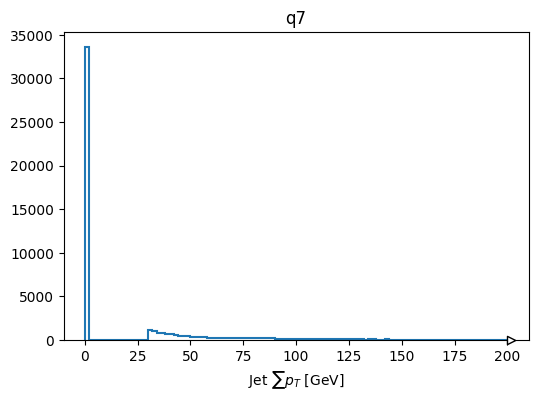

In [18]:
out = adl.run_query("q7", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## **Q8** — Transverse mass of MET + the leading light lepton outside the best same-flavor opposite-charge pair.

In [19]:
print(inspect.getsource(adl.QUERIES["q8"]))

def q8(g: Any) -> Any:
    """Transverse mass of MET + the leading light lepton outside the best SFOS pair."""
    mu = muons(g)
    el = electrons(g)
    mu = gak.with_field(mu, -13 * mu.charge, "pdgId")
    el = gak.with_field(el, -11 * el.charge, "pdgId")
    lep = gak.concatenate([el, mu], axis=1)

    mask3 = gak.num(lep, axis=1) >= 3
    lep = lep[mask3]
    met_pt = g.MET_pt[mask3]
    met_phi = g.MET_phi[mask3]

    pair = gak.argcombinations(lep, 2, fields=["l1", "l2"])
    sfos = pair[lep[pair.l1].pdgId == -lep[pair.l2].pdgId]
    mass = (lep[sfos.l1] + lep[sfos.l2]).mass
    best = gak.singletons(gak.argmin(abs(mass - 91.2), axis=1))
    best_pair = sfos[best]

    has_pair = gak.num(best_pair, axis=1) > 0
    lep = lep[has_pair]
    met_pt = met_pt[has_pair]
    met_phi = met_phi[has_pair]
    chosen = gak.firsts(best_pair[has_pair])

    idx = gak.local_index(lep, axis=1)
    outside = (idx != chosen.l1) & (idx != chosen.l2)
    others = lep[outside]
    lead = others[gak.

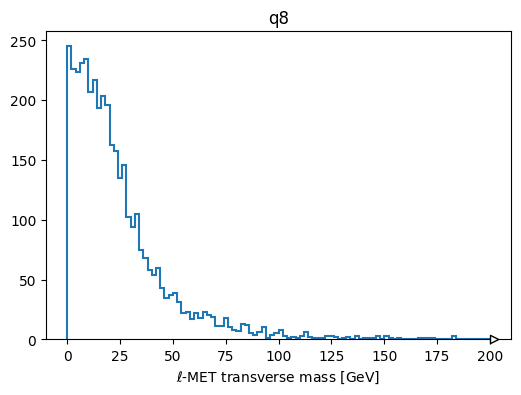

In [20]:
out = adl.run_query("q8", WHERE, steps_per_file=4)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

## Going parallel

Every query's `plan()` is an ordinary graphed task graph — run it with the process-pool executor
instead (vector behaviors travel to the workers **by import ref**, never pickled):

```python
from graphed_exec_local import ProcessExecutor
out = adl.run_query("q6", WHERE, steps_per_file=8, executor=ProcessExecutor(max_workers=4))
```